# Hawkes Time-Rescaling Goodness-of-Fit Diagnostics

This notebook simulates univariate Hawkes processes with several kernel shapes and checks the time-rescaling theorem. If the conditional intensity is correct, the compensator values at event times form a unit-rate Poisson process, so compensator increments should be iid `Exp(1)`.

The first diagnostics use the simulator's true compensator, so they test simulation, kernel primitives, and compensator evaluation. The fitted-model diagnostics then repeat the same checks after estimating a model from the simulated events.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

try:
    import pandas as pd
except ImportError:  # pandas is optional for nicer tables
    pd = None

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "our_hawkes").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Run this notebook from inside the our-hawkes checkout")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from our_hawkes.base import TimeFunction
from our_hawkes.hawkes import (
    HawkesEM,
    HawkesExpKern,
    HawkesKernelExp,
    HawkesKernelPowerLaw,
    HawkesKernelSumExp,
    HawkesKernelTimeFunc,
    HawkesSumExpKern,
    SimuHawkes,
    SimuHawkesExpKernels,
    SimuHawkesSumExpKernels,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=4, suppress=True)


## Diagnostic Helpers

For event times `t_i`, the residuals below are `z_i = Lambda(t_i) - Lambda(t_{i-1})`, with `Lambda(t_0)=0` for simulator-based compensators. A well-specified model should give residuals close to iid exponential variables with mean 1.


In [2]:
def kernel_matrix(kernel):
    kernels = np.empty((1, 1), dtype=object)
    kernels[0, 0] = kernel
    return kernels


def simulate_univariate_hawkes(name, kernel, baseline, max_jumps, seed):
    simulation = SimuHawkes(
        kernels=kernel_matrix(kernel),
        baseline=np.array([baseline], dtype=float),
        max_jumps=max_jumps,
        seed=seed,
        verbose=False,
    )
    simulation.simulate()
    simulation.store_compensator_values()
    return {
        "name": name,
        "kernel": kernel,
        "baseline": baseline,
        "simulation": simulation,
    }


def residuals_from_compensator_values(compensator_values, include_first=True):
    values = np.asarray(compensator_values, dtype=float)
    if include_first:
        residuals = np.diff(np.r_[0.0, values])
    else:
        residuals = np.diff(values)
    return residuals[np.isfinite(residuals) & (residuals > 0)]


def residuals_from_simulation(simulation):
    simulation.store_compensator_values()
    return residuals_from_compensator_values(simulation.tracked_compensator[0])


def lag_autocorrelation(values, lag):
    values = np.asarray(values, dtype=float)
    if values.size <= lag + 1:
        return np.nan
    x = values[:-lag] - np.mean(values[:-lag])
    y = values[lag:] - np.mean(values[lag:])
    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom == 0:
        return np.nan
    return float(np.dot(x, y) / denom)


def residual_summary(case, residuals):
    residuals = np.asarray(residuals, dtype=float)
    uniforms = 1.0 - np.exp(-residuals)
    ks_exp = stats.kstest(residuals, "expon")
    ks_uniform = stats.kstest(uniforms, "uniform")
    return {
        "case": case,
        "n": int(residuals.size),
        "mean": float(np.mean(residuals)),
        "variance": float(np.var(residuals, ddof=1)) if residuals.size > 1 else np.nan,
        "KS Exp(1) p": float(ks_exp.pvalue),
        "KS Uniform p": float(ks_uniform.pvalue),
        "lag-1 corr": lag_autocorrelation(residuals, 1),
    }


def show_table(rows):
    if pd is not None:
        display(pd.DataFrame(rows).set_index("case"))
        return
    headers = ["case", "n", "mean", "variance", "KS Exp(1) p", "KS Uniform p", "lag-1 corr"]
    print(" | ".join(headers))
    print("-" * 100)
    for row in rows:
        print(" | ".join(
            f"{row[h]:.4g}" if isinstance(row[h], float) else str(row[h])
            for h in headers
        ))


def plot_residual_diagnostics(results, title):
    fig, axes = plt.subplots(len(results), 3, figsize=(13, 3.2 * len(results)), squeeze=False)
    fig.suptitle(title, y=1.005, fontsize=14)
    for row_axes, (label, residuals) in zip(axes, results):
        residuals = np.asarray(residuals, dtype=float)
        upper = max(np.quantile(residuals, 0.995), 3.0)
        xs = np.linspace(0.0, upper, 300)

        ax = row_axes[0]
        ax.hist(residuals, bins=min(35, max(10, residuals.size // 8)), density=True, alpha=0.7)
        ax.plot(xs, stats.expon.pdf(xs), color="black", linewidth=1.5, label="Exp(1) PDF")
        ax.set_title(f"{label}: residual histogram")
        ax.set_xlabel("compensator increment")
        ax.legend()

        ax = row_axes[1]
        probs = (np.arange(1, residuals.size + 1) - 0.5) / residuals.size
        theoretical = stats.expon.ppf(probs)
        observed = np.sort(residuals)
        ax.scatter(theoretical, observed, s=12, alpha=0.7)
        limit = max(np.max(theoretical), np.max(observed))
        ax.plot([0, limit], [0, limit], color="black", linewidth=1.0)
        ax.set_title("Exp(1) QQ plot")
        ax.set_xlabel("theoretical quantiles")
        ax.set_ylabel("observed quantiles")

        ax = row_axes[2]
        max_lag = min(20, residuals.size // 3)
        lags = np.arange(1, max_lag + 1)
        acf = np.array([lag_autocorrelation(residuals, int(lag)) for lag in lags])
        ax.axhline(0.0, color="black", linewidth=1.0)
        ax.stem(lags, acf, basefmt=" ")
        ax.set_ylim(-1.0, 1.0)
        ax.set_title("residual autocorrelation")
        ax.set_xlabel("lag")
    fig.tight_layout()
    return fig


## Simulate Four Univariate Hawkes Processes

The examples use `max_jumps` instead of a fixed horizon so the notebook runs quickly and produces comparable residual sample sizes. Increase `max_jumps` if you want higher-power goodness-of-fit tests.


In [3]:
time_function = TimeFunction(
    (
        np.array([0.0, 0.2, 0.8, 1.5, 3.0, 4.0]),
        np.array([0.0, 0.5, 0.3, 0.1, 0.02, 0.0]),
    ),
    inter_mode=TimeFunction.InterLinear,
)

case_specs = [
    {
        "name": "exponential kernel",
        "kernel": HawkesKernelExp(intensity=0.45, decay=1.6),
        "baseline": 0.8,
        "max_jumps": 1000,
        "seed": 420,
    },
    {
        "name": "sum-exponential kernel",
        "kernel": HawkesKernelSumExp(intensities=[0.28, 0.17], decays=[0.35, 4.0]),
        "baseline": 0.8,
        "max_jumps": 1000,
        "seed": 69,
    },
    {
        "name": "power-law kernel",
        "kernel": HawkesKernelPowerLaw(multiplier=0.12, cutoff=1.0, exponent=1.7, support=4.0),
        "baseline": 1.0,
        "max_jumps": 100,
        "seed": 103,
    },
    {
        "name": "time-function kernel",
        "kernel": HawkesKernelTimeFunc(time_function),
        "baseline": 0.8,
        "max_jumps": 100,
        "seed": 104,
    },
]

cases = [simulate_univariate_hawkes(**spec) for spec in case_specs]

for case in cases:
    sim = case["simulation"]
    print(
        f"{case['name']}: jumps={sim.n_total_jumps}, "
        f"simulation_time={sim.simulation_time:.3f}, "
        f"kernel_norm={case['kernel'].get_norm():.3f}"
    )


exponential kernel: jumps=1000, simulation_time=695.884, kernel_norm=0.450
sum-exponential kernel: jumps=1000, simulation_time=642.046, kernel_norm=0.450
power-law kernel: jumps=100, simulation_time=78.298, kernel_norm=0.116
time-function kernel: jumps=100, simulation_time=77.584, kernel_norm=0.530


## Goodness of Fit With the True Compensator

These are oracle diagnostics because they use the same kernel and baseline that generated the data. The KS p-values should not be interpreted as proof that the model is correct; they are a compact smoke test that the residuals look compatible with `Exp(1)` and `Uniform(0, 1)` after the exponential CDF transform.


In [23]:
true_results = []
true_rows = []
for case in cases:
    residuals = residuals_from_simulation(case["simulation"])
    true_results.append((case["name"], residuals))
    true_rows.append(residual_summary(case["name"], residuals))

show_table(true_rows) 


,n,mean,variance,KS Exp(1) p,KS Uniform p,lag-1 corr
case,,,,,,
exponential kernel,1000,1.006204,0.962046,0.774074,0.774074,-0.032996
sum-exponential kernel,1000,0.961296,0.806249,0.664353,0.664353,0.022590
power-law kernel,100,0.893810,0.846693,0.598625,0.598625,-0.042376
time-function kernel,100,1.136978,1.080607,0.092690,0.092690,-0.075582


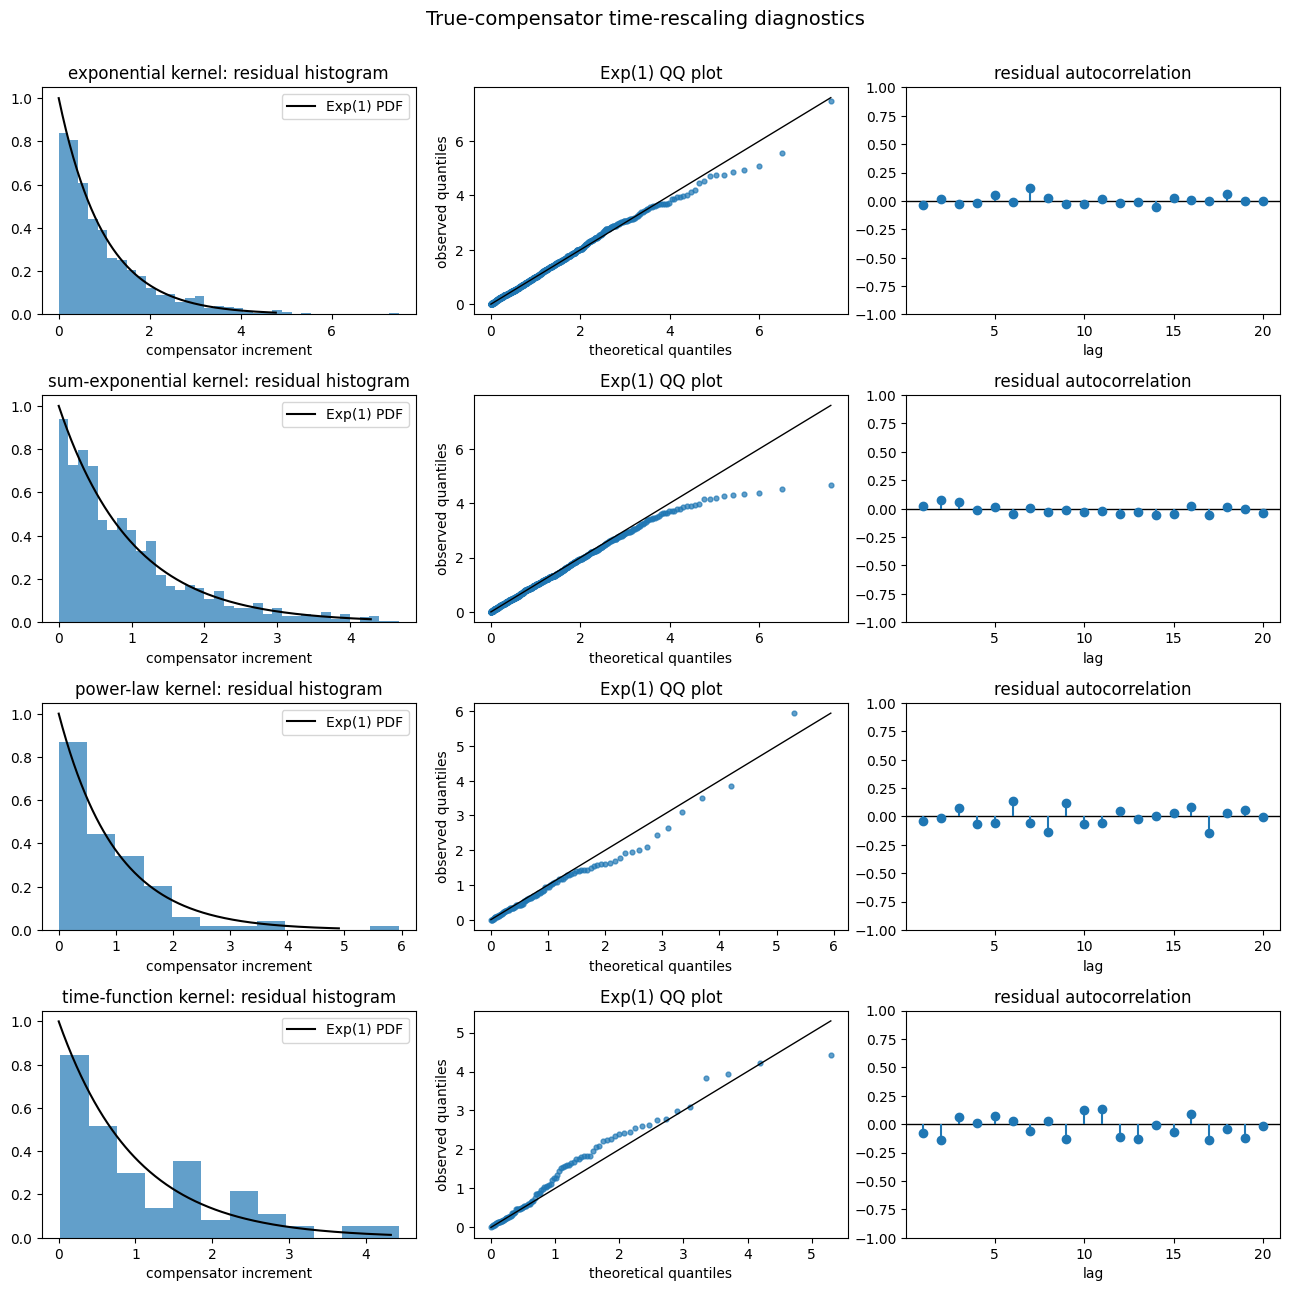

In [24]:
%matplotlib inline
fig = plot_residual_diagnostics(true_results, "True-compensator time-rescaling diagnostics")
plt.show()


## Fitted-Model Diagnostics

For exponential and sum-exponential simulations, we fit the matching parametric learner with the true decay grid fixed. For the time-function kernel, we fit a non-parametric `HawkesEM` model. We also fit a deliberately misspecified single-exponential model to the sum-exponential data.


In [17]:
def fitted_exp_residuals(simulation, decay, label, max_iter=50):
    learner = HawkesExpKern(
        decays=decay,
        gofit="likelihood",
        penalty="none",
        solver="agd",
        max_iter=max_iter,
        tol=1e-5,
        verbose=False,
    )
    learner.fit(simulation.timestamps, end_times=simulation.simulation_time)
    fitted = SimuHawkesExpKernels(
        adjacency=learner.adjacency,
        decays=learner.decays,
        baseline=learner.baseline,
        force_simulation=True,
        verbose=False,
    )
    fitted.set_timestamps(simulation.timestamps, end_time=simulation.simulation_time)
    residuals = residuals_from_simulation(fitted)
    return label, residuals, learner


def fitted_sumexp_residuals(simulation, decays, label, max_iter=50):
    learner = HawkesSumExpKern(
        decays=np.asarray(decays, dtype=float),
        penalty="none",
        solver="agd",
        max_iter=max_iter,
        tol=1e-5,
        verbose=False,
    )
    learner.fit(simulation.timestamps, end_times=simulation.simulation_time)
    fitted = SimuHawkesSumExpKernels(
        adjacency=learner.adjacency,
        decays=learner.decays,
        baseline=learner.baseline,
        force_simulation=True,
        verbose=False,
    )
    fitted.set_timestamps(simulation.timestamps, end_time=simulation.simulation_time)
    residuals = residuals_from_simulation(fitted)
    return label, residuals, learner


def fitted_em_residuals(simulation, support, kernel_size, label, max_iter=8):
    learner = HawkesEM(
        kernel_support=support,
        kernel_size=kernel_size,
        max_iter=max_iter,
        tol=1e-4,
        verbose=False,
    )
    learner.fit(simulation.timestamps, end_times=simulation.simulation_time)
    residuals = learner.time_changed_interarrival_times()[0][0]
    residuals = residuals[np.isfinite(residuals) & (residuals > 0)]
    return label, residuals, learner


In [34]:
case_by_name = {case["name"]: case for case in cases}

fitted_results = []
fitted_learners = {}

label, residuals, learner = fitted_exp_residuals(
    case_by_name["exponential kernel"]["simulation"],
    decay=1.6,
    label="fit exp model to exp data",
)
fitted_results.append((label, residuals))
fitted_learners[label] = learner

label, residuals, learner = fitted_sumexp_residuals(
    case_by_name["sum-exponential kernel"]["simulation"],
    decays=[0.35, 4.0],
    label="fit sum-exp model to sum-exp data",
)
fitted_results.append((label, residuals))
fitted_learners[label] = learner

label, residuals, learner = fitted_em_residuals(
    case_by_name["time-function kernel"]["simulation"],
    support=4.0,
    kernel_size=16,
    label="fit EM model to time-function data",
)
fitted_results.append((label, residuals))
fitted_learners[label] = learner

label, residuals, learner = fitted_exp_residuals(
    case_by_name["sum-exponential kernel"]["simulation"],
    decay=0.2,
    label="misspecified exp model on sum-exp data",
)
fitted_results.append((label, residuals))
fitted_learners[label] = learner

show_table([residual_summary(label, residuals) for label, residuals in fitted_results])


,n,mean,variance,KS Exp(1) p,KS Uniform p,lag-1 corr
case,,,,,,
fit exp model to exp data,1000,0.999879,0.960252,0.848588,0.848588,-0.030056
fit sum-exp model to sum-exp data,1000,1.000020,0.914374,0.710606,0.710606,0.031271
fit EM model to time-function data,99,0.997940,0.877412,0.862395,0.862395,-0.022615
misspecified exp model on sum-exp data,1000,0.999961,1.148318,0.001668,0.001668,0.080178


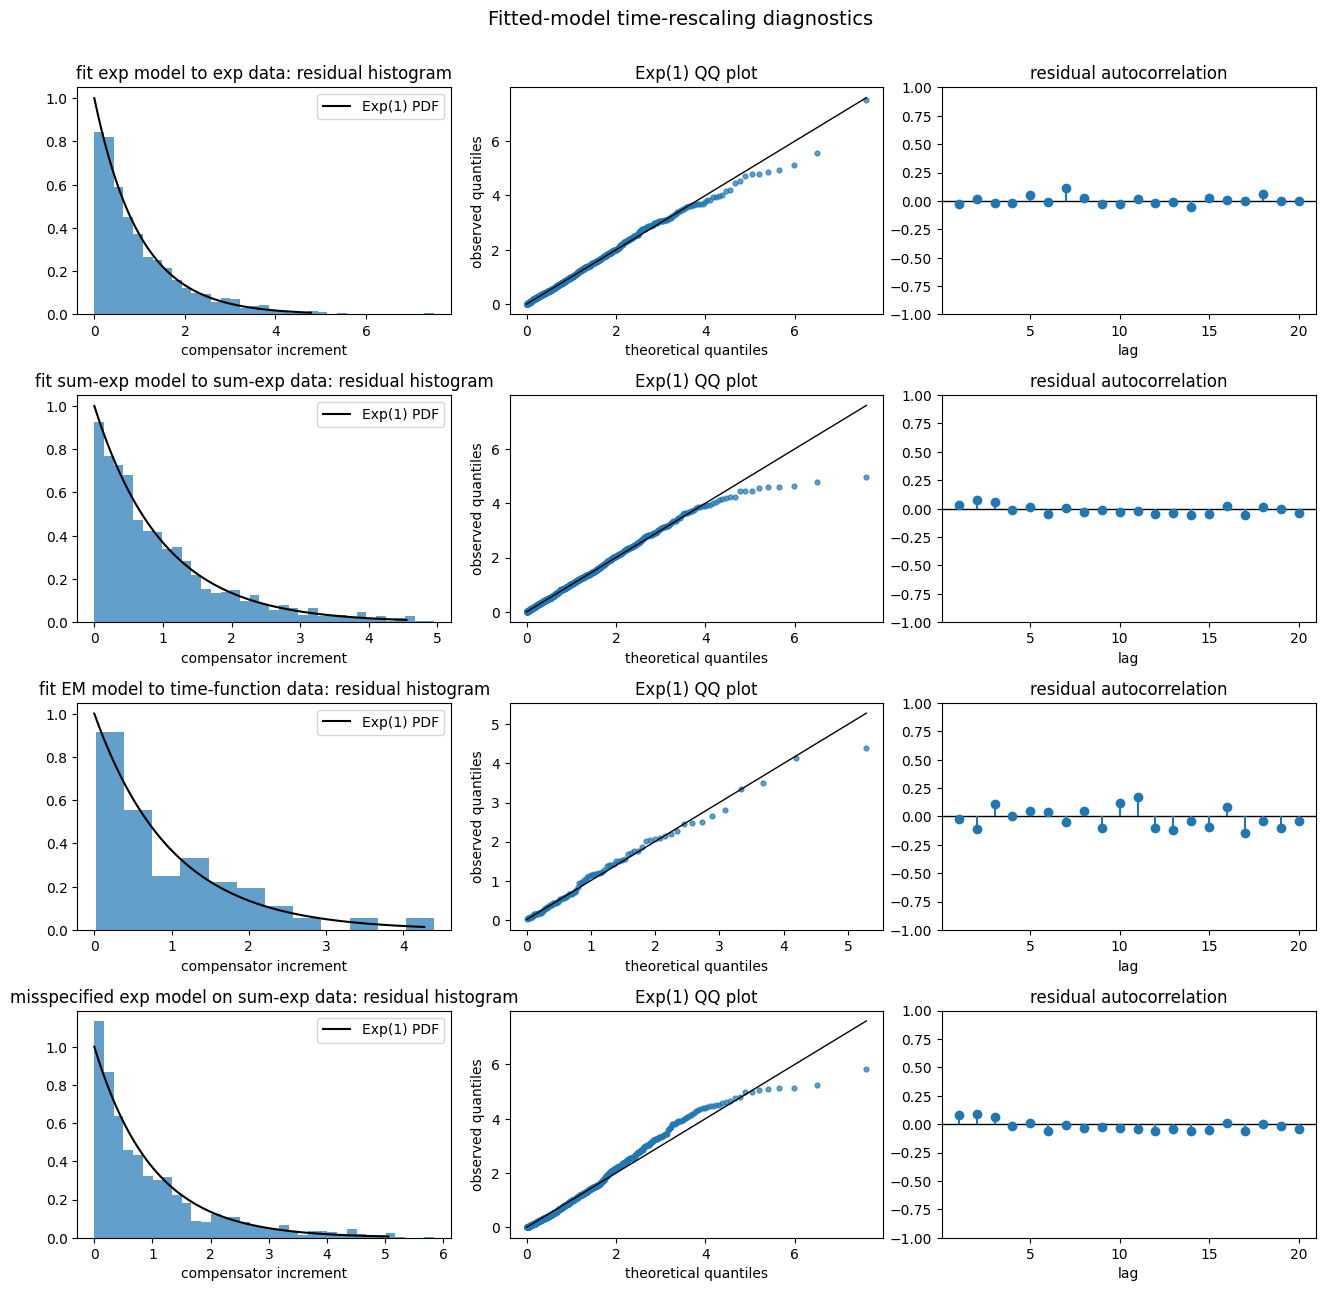

In [35]:
fig = plot_residual_diagnostics(fitted_results, "Fitted-model time-rescaling diagnostics")
plt.show()


## Interpretation

A good fit should have residual mean close to 1, variance close to 1, KS p-values that do not look systematically tiny, and small residual autocorrelations. The plots are often more informative than a single p-value: finite samples and fitted parameters make the KS test approximate, while the QQ plot and autocorrelation panel show where a model is misspecified.

For a stronger statistical check, increase `max_jumps`, rerun several seeds, and evaluate the p-value distribution rather than relying on one simulated path.


## Multivariate Hawkes Diagnostics

For a multivariate point process, there are two useful time-rescaling views. Component-wise compensators test whether each node's events look like a unit-rate Poisson process after applying that node's integrated intensity. The pooled process test uses the total conditional intensity `sum_i lambda_i(t)` across all marked events; its compensator increments should also be `Exp(1)`.

The marked-process check below also compares observed event counts by node with the expected counts from the model-implied mark probabilities `lambda_i(t) / sum_j lambda_j(t)` at each jump time.


In [4]:
def ordered_marked_events(simulation):
    events = []
    for node, timestamps in enumerate(simulation.timestamps):
        events.extend((float(t), node) for t in timestamps)
    return sorted(events)


def total_compensator_at(simulation, t):
    # tracked_compensator stores each component only at its own jumps; this
    # diagnostic needs all component compensators at every marked jump time.
    return float(sum(simulation._evaluate_compensator(node, float(t)) for node in range(simulation.n_nodes)))


def pooled_residuals_from_simulation(simulation):
    events = ordered_marked_events(simulation)
    total_values = np.asarray([total_compensator_at(simulation, t) for t, _ in events], dtype=float)
    return residuals_from_compensator_values(total_values)


def mark_calibration_summary(simulation):
    observed = np.zeros(simulation.n_nodes, dtype=float)
    expected = np.zeros(simulation.n_nodes, dtype=float)
    for t, node in ordered_marked_events(simulation):
        observed[node] += 1.0
        intensities = np.maximum(simulation._intensity_at(t, include_current_jumps=False), 0.0)
        total = float(np.sum(intensities))
        if total > 0:
            expected += intensities / total
        else:
            expected += np.full(simulation.n_nodes, 1.0 / simulation.n_nodes)
    statistic = float(np.sum((observed - expected) ** 2 / np.maximum(expected, 1e-12)))
    p_value = float(stats.chi2.sf(statistic, simulation.n_nodes - 1))
    return observed, expected, statistic, p_value


def show_mark_calibration(observed, expected, statistic, p_value):
    rows = [
        {"node": i, "observed events": observed[i], "expected events": expected[i]}
        for i in range(observed.size)
    ]
    if pd is not None:
        display(pd.DataFrame(rows).set_index("node"))
    else:
        for row in rows:
            print(row)
    print(f"mark chi-square statistic={statistic:.4f}, p-value={p_value:.4f}")


In [9]:
multivariate_adjacency = np.array([
    [0.18, 0.08, 0.03],
    [0.04, 0.16, 0.10],
    [0.06, 0.03, 0.14],
])
multivariate_baseline = np.array([0.35, 0.30, 0.25])
multivariate_decay = 1.4

multivariate_sim = SimuHawkesExpKernels(
    adjacency=multivariate_adjacency,
    decays=multivariate_decay,
    baseline=multivariate_baseline,
    max_jumps=2500,
    seed=225,
    verbose=False,
)
multivariate_sim.simulate()
multivariate_sim.store_compensator_values()

print(f"jumps={multivariate_sim.n_total_jumps}")
print(f"simulation_time={multivariate_sim.simulation_time:.3f}")
print(f"spectral_radius={multivariate_sim.spectral_radius():.3f}")
print("events by node:", [len(timestamps) for timestamps in multivariate_sim.timestamps])


jumps=2500
simulation_time=2024.632
spectral_radius=0.274
events by node: [954, 880, 666]


In [10]:
multivariate_results = [("pooled total-intensity process", pooled_residuals_from_simulation(multivariate_sim))]
for node, compensator_values in enumerate(multivariate_sim.tracked_compensator):
    multivariate_results.append((
        f"component {node} compensator process",
        residuals_from_compensator_values(compensator_values),
    ))

show_table([residual_summary(label, residuals) for label, residuals in multivariate_results])


,n,mean,variance,KS Exp(1) p,KS Uniform p,lag-1 corr
case,,,,,,
pooled total-intensity process,2500,1.002572,0.996475,0.991436,0.991436,0.011382
component 0 compensator process,954,1.014680,1.097486,0.720909,0.720909,0.000992
component 1 compensator process,880,0.969074,0.851298,0.649686,0.649686,0.022979
component 2 compensator process,666,1.024003,0.987983,0.567715,0.567715,0.026469


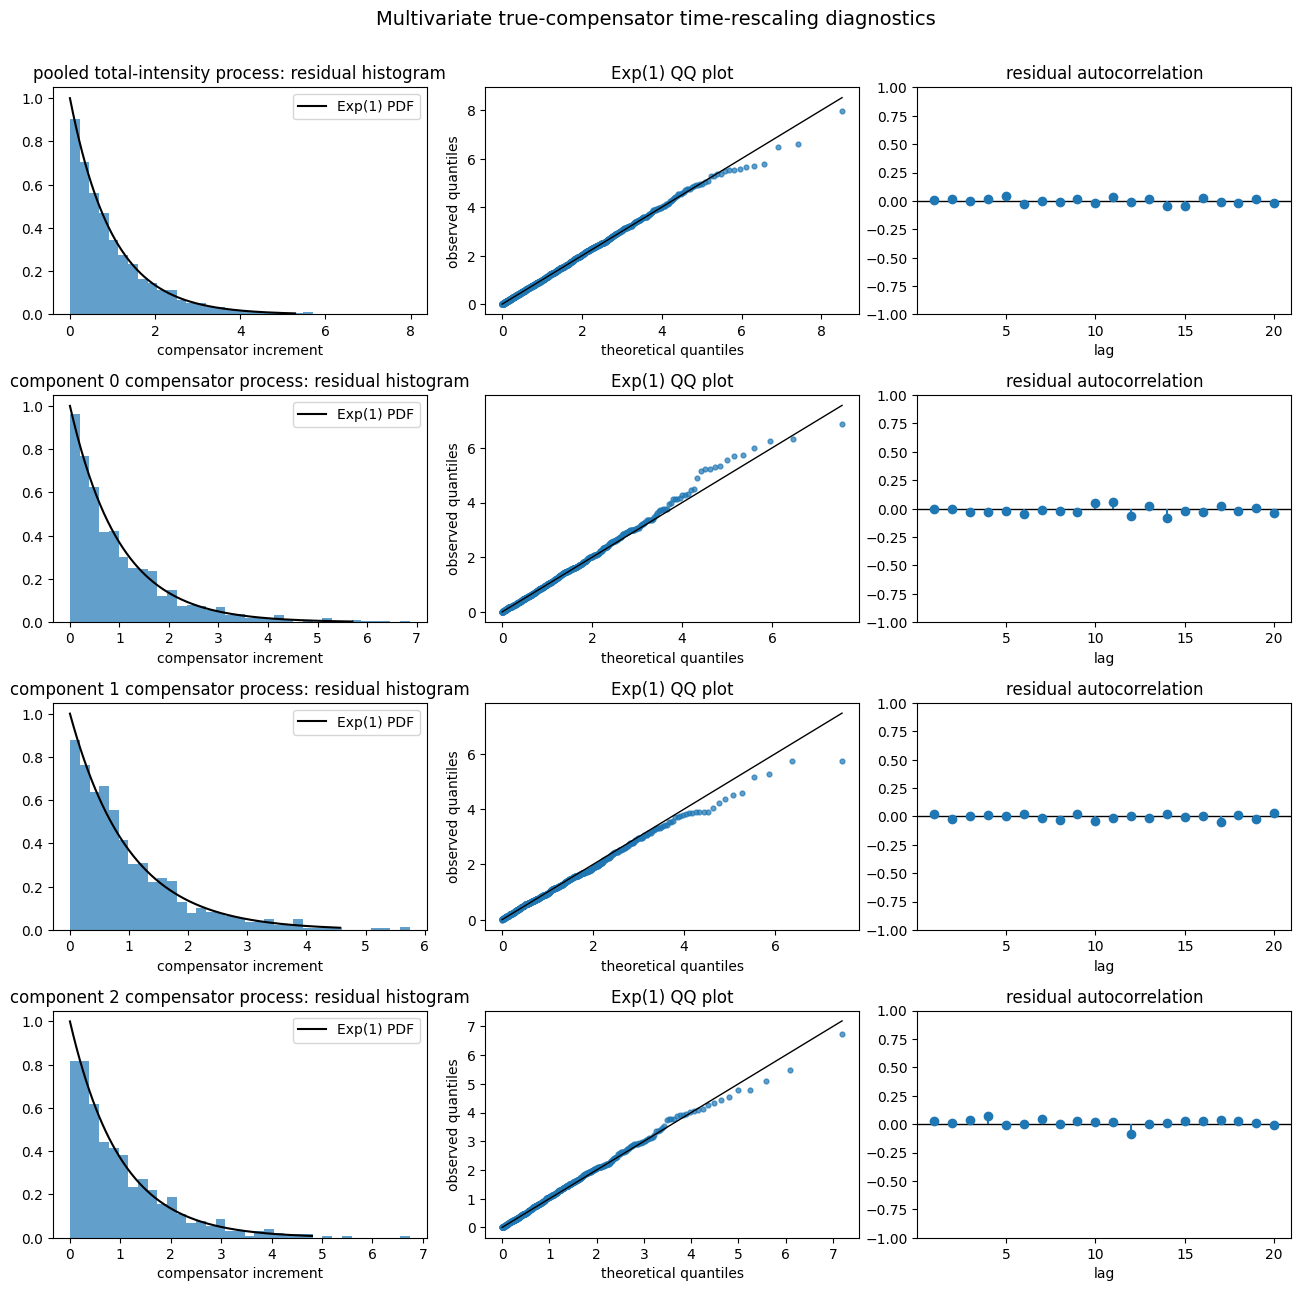

In [11]:
fig = plot_residual_diagnostics(
    multivariate_results,
    "Multivariate true-compensator time-rescaling diagnostics",
)
plt.show()


In [12]:
observed_marks, expected_marks, mark_statistic, mark_p_value = mark_calibration_summary(multivariate_sim)
show_mark_calibration(observed_marks, expected_marks, mark_statistic, mark_p_value)


,observed events,expected events
node,,
0,954.0,967.041531
1,880.0,851.623638
2,666.0,681.334831


mark chi-square statistic=1.4665, p-value=0.4803


The pooled residual row checks the timing of all marked events together. The component rows check each node separately. The mark calibration table asks whether the distribution of node labels is compatible with the conditional mark probabilities implied by the multivariate intensity.


## Additional Multivariate Cases

This section adds two harder checks:

1. A three-dimensional exponential Hawkes process with event marks. The mark function is non-constant and changes the future excitation caused by each event.
2. A three-dimensional Hawkes process whose kernel matrix mixes exponential and power-law kernels.

The marked simulation is implemented directly in the notebook because `SimuHawkesExpKernels` models node labels but not a separate mark variable that feeds back into future intensity.

### Marked Exponential Hawkes With Non-Constant Mark Function

The model is

```text
lambda_i(t) = mu_i + sum_j sum_{t_k^j < t} alpha_ij * beta * exp(-beta * (t - t_k^j)) * g(m_k^j)
```

with non-constant mark function

```text
g(m) = 0.5 + 0.5 m
```

Marks are sampled independently after each accepted event, conditional on the event's source node. The mark affects future excitation, not the current event's node assignment.

In [ ]:
def nonconstant_mark_function(mark):
    return 0.5 + 0.5 * float(mark)


def sample_component_mark(rng, node):
    shape = 2.0 + 0.25 * node
    return float(rng.gamma(shape=shape, scale=1.0 / shape))


def simulate_marked_exp_hawkes(baseline, adjacency, decay, max_jumps, seed):
    rng = np.random.default_rng(seed)
    baseline = np.asarray(baseline, dtype=float)
    adjacency = np.asarray(adjacency, dtype=float)
    n_nodes = baseline.size
    time = 0.0
    excitation = np.zeros(n_nodes, dtype=float)
    events = []
    timestamps = [[] for _ in range(n_nodes)]
    marks = [[] for _ in range(n_nodes)]

    while len(events) < max_jumps:
        intensity_bound = baseline + excitation
        total_bound = float(np.sum(intensity_bound))
        if total_bound <= 0:
            break
        wait = rng.exponential(1.0 / total_bound)
        time += wait
        excitation *= np.exp(-decay * wait)
        intensity = baseline + excitation
        total_intensity = float(np.sum(intensity))
        if rng.uniform() * total_bound > total_intensity:
            continue
        node = int(np.searchsorted(np.cumsum(intensity), rng.uniform() * total_intensity, side="right"))
        node = min(node, n_nodes - 1)
        mark = sample_component_mark(rng, node)
        mark_weight = nonconstant_mark_function(mark)
        events.append((time, node, mark, mark_weight))
        timestamps[node].append(time)
        marks[node].append(mark)
        excitation += adjacency[:, node] * decay * mark_weight

    return {
        "baseline": baseline,
        "adjacency": adjacency,
        "decay": float(decay),
        "events": events,
        "timestamps": [np.asarray(values, dtype=float) for values in timestamps],
        "marks": [np.asarray(values, dtype=float) for values in marks],
    }


def marked_exp_intensity_at(process, t):
    baseline = process["baseline"]
    adjacency = process["adjacency"]
    decay = process["decay"]
    intensity = baseline.copy()
    for event_time, source_node, mark, mark_weight in process["events"]:
        if event_time >= t:
            break
        lag = t - event_time
        intensity += adjacency[:, source_node] * decay * np.exp(-decay * lag) * mark_weight
    return np.maximum(intensity, 0.0)


def marked_exp_component_compensator(process, node, t):
    value = process["baseline"][node] * t
    decay = process["decay"]
    for event_time, source_node, mark, mark_weight in process["events"]:
        if event_time >= t:
            break
        value += process["adjacency"][node, source_node] * mark_weight * (
            1.0 - np.exp(-decay * (t - event_time))
        )
    return float(value)


def marked_exp_pooled_residuals(process):
    total_compensators = [
        sum(marked_exp_component_compensator(process, node, event_time) for node in range(process["baseline"].size))
        for event_time, _, _, _ in process["events"]
    ]
    return residuals_from_compensator_values(total_compensators)


def marked_exp_component_residuals(process, node):
    values = [
        marked_exp_component_compensator(process, node, event_time)
        for event_time in process["timestamps"][node]
    ]
    return residuals_from_compensator_values(values)


def marked_exp_mark_calibration(process):
    n_nodes = process["baseline"].size
    observed = np.zeros(n_nodes, dtype=float)
    expected = np.zeros(n_nodes, dtype=float)
    for event_time, node, mark, mark_weight in process["events"]:
        observed[node] += 1.0
        intensity = marked_exp_intensity_at(process, event_time)
        total = float(np.sum(intensity))
        if total > 0:
            expected += intensity / total
    statistic = float(np.sum((observed - expected) ** 2 / np.maximum(expected, 1e-12)))
    p_value = float(stats.chi2.sf(statistic, n_nodes - 1))
    return observed, expected, statistic, p_value


In [ ]:
marked_process = simulate_marked_exp_hawkes(
    baseline=np.array([0.28, 0.25, 0.22]),
    adjacency=np.array([
        [0.18, 0.07, 0.04],
        [0.05, 0.16, 0.09],
        [0.07, 0.04, 0.14],
    ]),
    decay=1.3,
    max_jumps=1600,
    seed=337,
)

marked_results = [("marked pooled total-intensity process", marked_exp_pooled_residuals(marked_process))]
for node in range(3):
    marked_results.append((f"marked component {node} compensator process", marked_exp_component_residuals(marked_process, node)))

print("events by node:", [len(values) for values in marked_process["timestamps"]])
show_table([residual_summary(label, residuals) for label, residuals in marked_results])


In [ ]:
fig = plot_residual_diagnostics(
    marked_results,
    "Marked exponential Hawkes time-rescaling diagnostics",
)
plt.show()


In [ ]:
marked_observed, marked_expected, marked_statistic, marked_p_value = marked_exp_mark_calibration(marked_process)
show_mark_calibration(marked_observed, marked_expected, marked_statistic, marked_p_value)

mark_rows = []
for node, node_marks in enumerate(marked_process["marks"]):
    weights = np.asarray([nonconstant_mark_function(mark) for mark in node_marks], dtype=float)
    mark_rows.append({
        "node": node,
        "n marks": int(node_marks.size),
        "mean mark": float(np.mean(node_marks)),
        "mean g(mark)": float(np.mean(weights)),
        "std g(mark)": float(np.std(weights, ddof=1)),
    })

if pd is not None:
    display(pd.DataFrame(mark_rows).set_index("node"))
else:
    for row in mark_rows:
        print(row)


### Mixed Power-Law and Exponential Kernels

The next process uses a 3-by-3 kernel matrix with both exponential and finite-support power-law entries. The simulation helper below uses Ogata thinning for non-increasing positive kernels and exact primitive evaluations for the compensator.

In [ ]:
def is_zero_kernel_entry(kernel):
    return isinstance(kernel, (int, float, np.integer, np.floating)) and float(kernel) == 0.0


def mixed_kernel_intensity_at(process, t):
    kernels = process["kernels"]
    baseline = process["baseline"]
    intensity = baseline.copy()
    for event_time, source_node in process["events"]:
        if event_time >= t:
            break
        lag = t - event_time
        for target_node in range(baseline.size):
            kernel = kernels[target_node, source_node]
            if not is_zero_kernel_entry(kernel):
                intensity[target_node] += kernel.get_value(lag)
    return np.maximum(intensity, 0.0)


def simulate_mixed_kernel_hawkes(kernels, baseline, max_jumps, seed):
    rng = np.random.default_rng(seed)
    baseline = np.asarray(baseline, dtype=float)
    n_nodes = baseline.size
    time = 0.0
    events = []
    timestamps = [[] for _ in range(n_nodes)]

    while len(events) < max_jumps:
        intensity_bound = mixed_kernel_intensity_at(
            {"kernels": kernels, "baseline": baseline, "events": events},
            time,
        )
        total_bound = float(np.sum(intensity_bound))
        if total_bound <= 0:
            break
        candidate_time = time + rng.exponential(1.0 / total_bound)
        candidate_intensity = mixed_kernel_intensity_at(
            {"kernels": kernels, "baseline": baseline, "events": events},
            candidate_time,
        )
        total_intensity = float(np.sum(candidate_intensity))
        time = candidate_time
        if rng.uniform() * total_bound > total_intensity:
            continue
        node = int(np.searchsorted(np.cumsum(candidate_intensity), rng.uniform() * total_intensity, side="right"))
        node = min(node, n_nodes - 1)
        events.append((time, node))
        timestamps[node].append(time)

    return {
        "kernels": kernels,
        "baseline": baseline,
        "events": events,
        "timestamps": [np.asarray(values, dtype=float) for values in timestamps],
    }


def mixed_kernel_component_compensator(process, node, t):
    value = process["baseline"][node] * t
    kernels = process["kernels"]
    for event_time, source_node in process["events"]:
        if event_time >= t:
            break
        kernel = kernels[node, source_node]
        if not is_zero_kernel_entry(kernel):
            value += kernel.get_primitive_value(t - event_time)
    return float(value)


def mixed_kernel_pooled_residuals(process):
    total_compensators = [
        sum(mixed_kernel_component_compensator(process, node, event_time) for node in range(process["baseline"].size))
        for event_time, _ in process["events"]
    ]
    return residuals_from_compensator_values(total_compensators)


def mixed_kernel_component_residuals(process, node):
    values = [
        mixed_kernel_component_compensator(process, node, event_time)
        for event_time in process["timestamps"][node]
    ]
    return residuals_from_compensator_values(values)


In [ ]:
mixed_kernels = np.empty((3, 3), dtype=object)
mixed_kernels[:, :] = 0
mixed_kernels[0, 0] = HawkesKernelExp(0.08, 1.4)
mixed_kernels[1, 1] = HawkesKernelExp(0.07, 1.2)
mixed_kernels[2, 2] = HawkesKernelPowerLaw(0.03, 1.0, 1.8, support=1.5)
mixed_kernels[0, 1] = HawkesKernelPowerLaw(0.02, 1.0, 1.9, support=1.5)
mixed_kernels[1, 2] = HawkesKernelExp(0.04, 1.6)
mixed_kernels[2, 0] = HawkesKernelPowerLaw(0.02, 1.0, 1.8, support=1.5)
mixed_kernels[0, 2] = HawkesKernelExp(0.02, 2.0)
mixed_kernels[1, 0] = HawkesKernelPowerLaw(0.02, 1.0, 1.9, support=1.5)
mixed_kernels[2, 1] = HawkesKernelExp(0.03, 1.2)

mixed_process = simulate_mixed_kernel_hawkes(
    kernels=mixed_kernels,
    baseline=np.array([0.6, 0.5, 0.45]),
    max_jumps=1200,
    seed=338,
)

mixed_results = [("mixed pooled total-intensity process", mixed_kernel_pooled_residuals(mixed_process))]
for node in range(3):
    mixed_results.append((f"mixed component {node} compensator process", mixed_kernel_component_residuals(mixed_process, node)))

print("events by node:", [len(values) for values in mixed_process["timestamps"]])
print("last event time:", round(mixed_process["events"][-1][0], 4))
show_table([residual_summary(label, residuals) for label, residuals in mixed_results])


In [ ]:
fig = plot_residual_diagnostics(
    mixed_results,
    "Mixed power-law/exponential Hawkes time-rescaling diagnostics",
)
plt.show()
